# cloudposterior: Cloud Execution

Run PyMC MCMC sampling on cloud VMs with one line of code. This notebook demonstrates remote execution using the classic Radon dataset from Gelman & Hill (2006).

> Run this notebook locally to see the interactive progress display. Some outputs don't render in GitHub's notebook viewer.

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

import cloudposterior as cp

## Data

919 household radon measurements across 85 Minnesota counties (Gelman & Hill, 2006).

In [2]:
df = pd.read_csv(pm.get_data("radon.csv"))

county_names = df.county.unique()
county_idx = df.county_code.values
log_radon = df.log_radon.values
floor = df.floor.values

print(f"{len(df)} observations, {len(county_names)} counties")

919 observations, 85 counties


## Model

Hierarchical varying-intercepts model with non-centered parameterization. Each county gets its own intercept (partial pooling), and floor level (basement vs first floor) is a fixed effect.

In [3]:
with pm.Model(name="radon_intercepts", coords={"county": county_names}) as radon:
    mu_a = pm.Normal("mu_a", mu=0, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", sigma=2)
    a_raw = pm.Normal("a_raw", mu=0, sigma=1, dims="county")
    a = pm.Deterministic("a", mu_a + sigma_a * a_raw, dims="county")
    b_floor = pm.Normal("b_floor", mu=0, sigma=5)
    mu = a[county_idx] + b_floor * floor
    sigma_y = pm.HalfNormal("sigma_y", sigma=2)
    pm.Normal("obs", mu=mu, sigma=sigma_y, observed=log_radon)

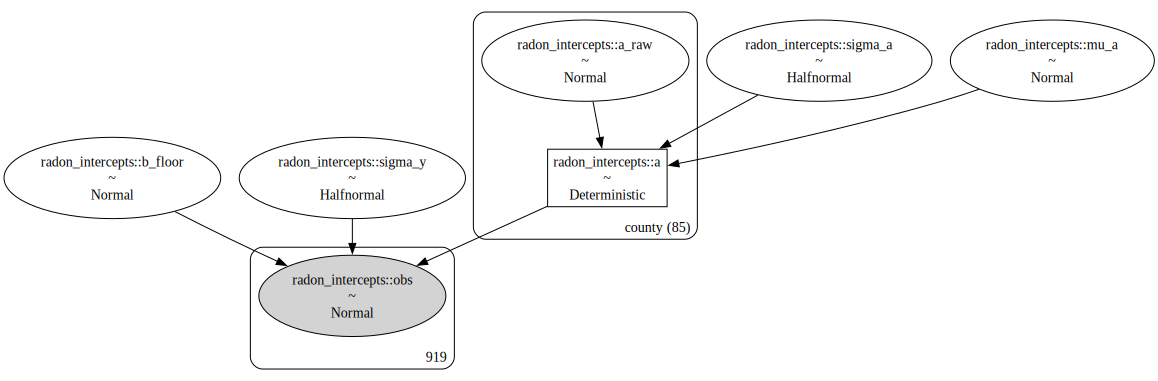

In [4]:
pm.model_to_graphviz(radon)

## Remote execution

`cp.cloud()` intercepts `pm.sample()` and runs it on a cloud VM. The model is uploaded to a volume on first run. Resources (CPU cores, memory) are auto-sized to your model.

In [5]:
with cp.cloud(radon, remote=True):
    idata = pm.sample(draws=2000, tune=1000, chains=4)

## Diagnostics

In [6]:
az.summary(idata, filter_vars="like", var_names=["mu_a", "sigma_a", "b_floor", "sigma_y"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
radon_intercepts::mu_a,1.490,0.051,1.396,1.586,0.001,0.001,3108.0,3478.0,1.0
radon_intercepts::b_floor,-0.663,0.069,-0.787,-0.529,0.001,0.001,8869.0,6789.0,1.0
radon_intercepts::sigma_a,0.323,0.046,0.242,0.410,0.001,0.001,2044.0,3372.0,1.0
radon_intercepts::sigma_y,0.727,0.018,0.695,0.760,0.000,0.000,8061.0,6205.0,1.0


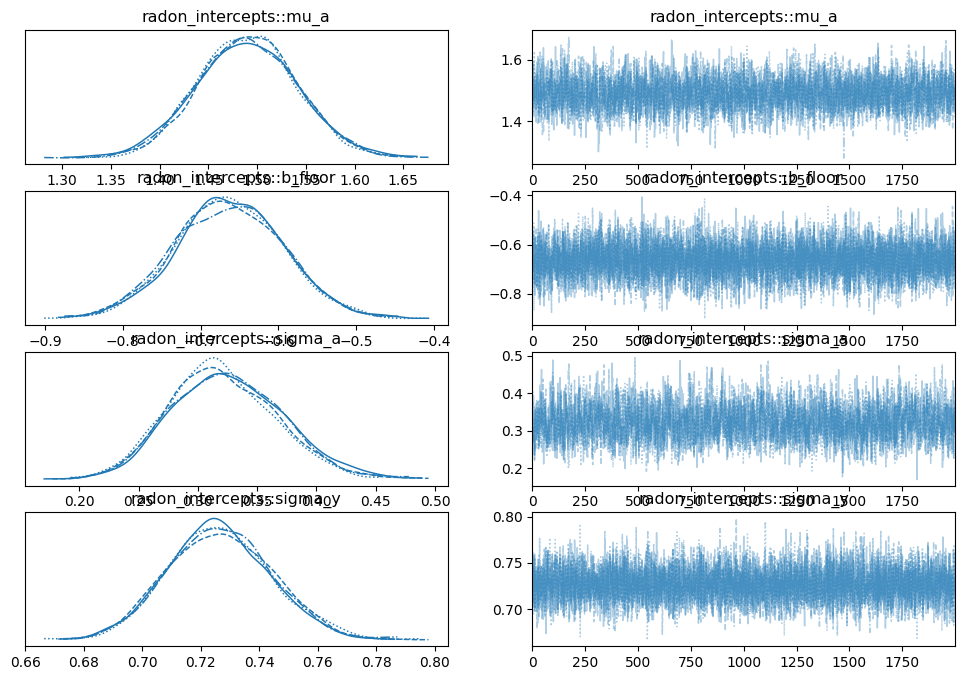

In [7]:
az.plot_trace(idata, filter_vars="like", var_names=["mu_a", "sigma_a", "b_floor", "sigma_y"]);

## GPU acceleration with JAX

For models that benefit from GPU acceleration, use `nuts_sampler="numpyro"` to sample with JAX via NumPyro. cloudposterior automatically provisions a GPU when it detects a JAX-based sampler -- no configuration needed.

The progress display shows the auto-sized resources including the GPU.

In [8]:
with cp.cloud(radon, remote=True):
    idata_jax = pm.sample(draws=2000, tune=1000, chains=4, nuts_sampler="numpyro")

## Cleanup

Model payloads are stored in a project-scoped volume. Delete it when you're done.

In [9]:
cp.cleanup_volumes()